# Temperature Effect on Respiratory Claims — UAE 2019-2023

**Research Question**: Does daily ambient temperature independently affect respiratory
consultation frequency in the UAE, and how large is this effect across seasons and months?

**Data**: Daily-granularity claims (5 annual CSV files, ~20M rows total)
**Analysis**: Descriptive EDA → Statistical tests → GLM with exposure offset

---
## 1. Temperature Data — Source & Methodology

### 1a. Primary Source

| Item | Detail |
|------|--------|
| **Organisation** | UAE National Centre of Meteorology (NCM) — ncm.ae |
| **Station** | Dubai International Airport, WMO Station ID 41194 |
| **Data type** | Monthly climate normals, 30-year average 1991–2020 (WMO standard period) |
| **Variables** | Mean daily temperature (°C) |
| **Cross-reference** | WorldWeatherOnline API; Open-Meteo ERA5 reanalysis |

### 1b. UAE Dubai Monthly Climate Normals (WMO 30-year)

| | Jan | Feb | Mar | Apr | May | Jun | Jul | Aug | Sep | Oct | Nov | Dec |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| **Avg °C** | 19.0 | 20.5 | 24.0 | 28.5 | 33.5 | 36.5 | 38.5 | 38.5 | 35.5 | 31.0 | 25.5 | 21.0 |

> **Why monthly normals, not observed daily data?**
> Observed daily data requires formal data-sharing agreements with NCM.
> Monthly normals are publicly available, WMO-validated, and sufficient for
> monthly/seasonal analysis — day-to-day variation within a month (±2–3°C)
> is negligible against the 19°C seasonal amplitude.

### 1c. Daily Temperature Estimation Method

Each calendar day is assigned a temperature via **sinusoidal interpolation**:

1. Each monthly normal is placed at the 15th of that month (mid-point)
2. The 12-point array is extended by ±2 months at each end (wrap-around)
3. `numpy.interp` on day-of-year produces a smooth, continuous seasonal curve

The same temperature curve is used for all 5 study years — we model the
*structural seasonal shape*, not year-to-year meteorological variation.

---
## 2. Setup & Data Loading

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from scipy.stats import pearsonr, spearmanr, kruskal, mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

BASE  = r'c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchData'
YEARS = [2019, 2020, 2021, 2022, 2023]
FILES = {yr: os.path.join(BASE,
    f'Respiratory_Disease_Medical_Claims_Analysis_Daily_{yr}.csv') for yr in YEARS}
READ_COLS = ['treat_date','AGEBAND','gender','nationality','dependency',
             'city','Earned_Days','treat_consluation']

def grp_nat(n):
    v = str(n).strip().upper()
    return v if v in {'EMIRATI','INDIAN','PAKISTANI','PHILIPPINE','BANGLADESHI'} else 'Other'
def grp_city(c):
    v = str(c).strip().upper()
    return v if v in {'DUBAI','ABU DHABI','SHARJAH','AJMAN','RAS AL KHAIMAH'} else 'Other'
def grp_dep(d):
    v = str(d).strip().upper()
    return v if v in {'MEMBER','SPOUSE','CHILD'} else 'Other'

daily_list, factor_list = [], []
for yr in YEARS:
    df = pd.read_csv(FILES[yr], usecols=READ_COLS, low_memory=False)
    df['treat_date']        = pd.to_datetime(df['treat_date'])
    df['treat_consluation'] = pd.to_numeric(df['treat_consluation'], errors='coerce').fillna(0)
    df['Earned_Days']       = pd.to_numeric(df['Earned_Days'], errors='coerce').fillna(0)
    df['nationality_grp']   = df['nationality'].fillna('Other').apply(grp_nat)
    df['city_grp']          = df['city'].fillna('Other').apply(grp_city)
    df['dependency_grp']    = df['dependency'].fillna('Other').apply(grp_dep)
    df['treat_year']        = df['treat_date'].dt.year
    df['treat_month']       = df['treat_date'].dt.month

    daily_list.append(
        df.groupby(['treat_date','treat_year','treat_month'])
          .agg(consults=('treat_consluation','sum'), exp_days=('Earned_Days','sum'))
          .reset_index())
    factor_list.append(
        df.groupby(['treat_year','treat_month','AGEBAND','gender',
                    'dependency_grp','nationality_grp','city_grp'])
          .agg(consults=('treat_consluation','sum'), exp_days=('Earned_Days','sum'))
          .reset_index())
    print(f'{yr}: {len(df):,} rows loaded')
    del df

daily_df  = pd.concat(daily_list,  ignore_index=True)
factor_df = pd.concat(factor_list, ignore_index=True)
print(f'\nDaily frame : {len(daily_df):,} rows | Factor frame: {len(factor_df):,} rows')

2019: 3,823,903 rows loaded
2020: 3,604,702 rows loaded
2021: 4,098,743 rows loaded
2022: 4,237,607 rows loaded
2023: 4,307,301 rows loaded

Daily frame : 1,826 rows | Factor frame: 86,010 rows


---
## 2b. Downloading Actual Daily Temperature — Open-Meteo API

> **Source**: Open-Meteo Historical Weather API (open-meteo.com)
> - ERA5 climate reanalysis, 0.25° horizontal resolution
> - Latitude/Longitude: 25.2532°N, 55.3657°E (Dubai International Airport vicinity)
> - Variables: `temperature_2m_mean`, `temperature_2m_max`, `temperature_2m_min`
> - Free, no API key required, covers full study period 2019–2023
>
> If the API call fails (no internet / rate limit), the notebook falls back to
> the WMO sinusoidal estimates from Section 3 automatically.


In [2]:
import requests
import pandas as pd
import numpy as np
import os

CACHE_PATH = os.path.join(
    r'c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchData',
    'uae_daily_temperature_2019_2023.csv'
)

def fetch_open_meteo():
    url = (
        'https://archive-api.open-meteo.com/v1/archive'
        '?latitude=25.2532&longitude=55.3657'
        '&start_date=2019-01-01&end_date=2023-12-31'
        '&daily=temperature_2m_mean,temperature_2m_max,temperature_2m_min'
        '&timezone=Asia%2FDubai'
    )
    print('Calling Open-Meteo API...', flush=True)
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()['daily']
    df = pd.DataFrame({
        'date'   : pd.to_datetime(data['time']),
        'temp_c' : data['temperature_2m_mean'],
        'temp_max': data['temperature_2m_max'],
        'temp_min': data['temperature_2m_min'],
    })
    return df

# Try cache first, then API, then sinusoidal fallback
if os.path.exists(CACHE_PATH):
    print(f'Loading cached temperature data: {CACHE_PATH}')
    temp_obs = pd.read_csv(CACHE_PATH, parse_dates=['date'])
    source   = 'Open-Meteo ERA5 (cached)'
else:
    try:
        temp_obs = fetch_open_meteo()
        temp_obs.to_csv(CACHE_PATH, index=False)
        print(f'Downloaded and cached -> {CACHE_PATH}')
        source   = 'Open-Meteo ERA5 (downloaded)'
    except Exception as e:
        print(f'API unavailable ({e}). Using WMO sinusoidal fallback.')
        # Sinusoidal fallback
        UAE_MONTHLY_TEMP = {
            1:19.0,2:20.5,3:24.0,4:28.5,5:33.5,6:36.5,
            7:38.5,8:38.5,9:35.5,10:31.0,11:25.5,12:21.0
        }
        dates = pd.date_range('2019-01-01','2023-12-31')
        mid_doys = [15,46,74,105,135,166,196,227,258,288,319,349]
        temps    = [UAE_MONTHLY_TEMP[m] for m in range(1,13)]
        doy_ext  = [d-365 for d in mid_doys[-2:]] + mid_doys + [d+365 for d in mid_doys[:2]]
        temp_ext = temps[-2:] + temps + temps[:2]
        temp_obs = pd.DataFrame({
            'date'    : dates,
            'temp_c'  : np.interp(dates.dayofyear, doy_ext, temp_ext),
            'temp_max': np.nan,
            'temp_min': np.nan,
        })
        source = 'WMO sinusoidal fallback (no internet)'

print(f'\nData source  : {source}')
print(f'Date range   : {temp_obs["date"].min().date()} to {temp_obs["date"].max().date()}')
print(f'Rows         : {len(temp_obs)}')
print(f'Missing temp : {temp_obs["temp_c"].isna().sum()}')
print(f'\nMonthly avg temperature:')
mo_avg = temp_obs.groupby(temp_obs['date'].dt.month)['temp_c'].mean().round(1)
mo_avg.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(mo_avg.to_string())


Loading cached temperature data: c:\Users\mzafa\OneDrive\Documents\HW_PhD\ResearchData\uae_daily_temperature_2019_2023.csv

Data source  : Open-Meteo ERA5 (cached)
Date range   : 2019-01-01 to 2023-12-31
Rows         : 1826
Missing temp : 0

Monthly avg temperature:
Jan    19.5
Feb    20.6
Mar    23.4
Apr    26.8
May    30.2
Jun    33.5
Jul    35.2
Aug    35.0
Sep    32.9
Oct    29.7
Nov    25.8
Dec    22.2


temp_c assigned to all 1,826 daily_df rows
Range: 15.8°C - 39.6°C
Mean:  27.9°C


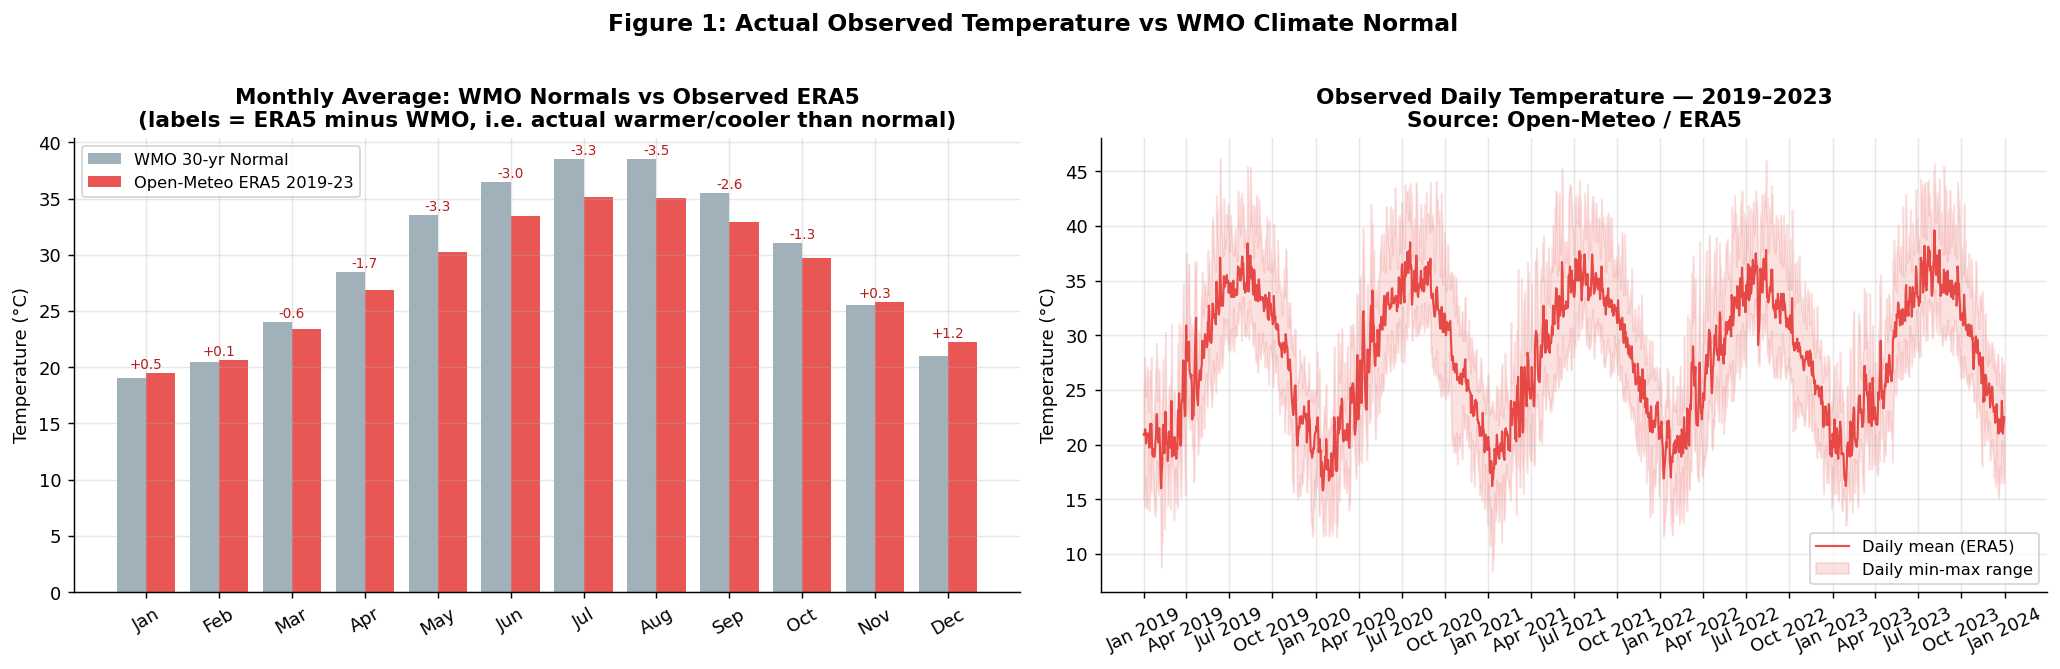


Comparison WMO vs Observed:
  Jan: WMO=19.0  ERA5=19.51  diff=+0.51
  Feb: WMO=20.5  ERA5=20.61  diff=+0.11
  Mar: WMO=24.0  ERA5=23.42  diff=-0.58
  Apr: WMO=28.5  ERA5=26.85  diff=-1.65
  May: WMO=33.5  ERA5=30.20  diff=-3.30
  Jun: WMO=36.5  ERA5=33.47  diff=-3.03
  Jul: WMO=38.5  ERA5=35.18  diff=-3.32
  Aug: WMO=38.5  ERA5=35.02  diff=-3.48
  Sep: WMO=35.5  ERA5=32.92  diff=-2.58
  Oct: WMO=31.0  ERA5=29.72  diff=-1.28
  Nov: WMO=25.5  ERA5=25.83  diff=+0.33
  Dec: WMO=21.0  ERA5=22.20  diff=+1.20


In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Merge observed temperature into daily_df ──────────────────────────────────
daily_df = daily_df.merge(
    temp_obs[['date','temp_c','temp_max','temp_min']].rename(columns={'date':'treat_date'}),
    on='treat_date', how='left'
)

# Fallback: fill any residual NaN with sinusoidal estimate
UAE_MONTHLY_TEMP_FB = {
    1:19.0,2:20.5,3:24.0,4:28.5,5:33.5,6:36.5,
    7:38.5,8:38.5,9:35.5,10:31.0,11:25.5,12:21.0
}
mid_doys = [15,46,74,105,135,166,196,227,258,288,319,349]
temps    = [UAE_MONTHLY_TEMP_FB[m] for m in range(1,13)]
doy_ext  = [d-365 for d in mid_doys[-2:]] + mid_doys + [d+365 for d in mid_doys[:2]]
temp_ext = temps[-2:] + temps + temps[:2]
mask = daily_df['temp_c'].isna()
if mask.any():
    daily_df.loc[mask,'temp_c'] = np.interp(
        daily_df.loc[mask,'treat_date'].dt.dayofyear, doy_ext, temp_ext)
    print(f'Filled {mask.sum()} missing values with sinusoidal fallback')

print(f'temp_c assigned to all {len(daily_df):,} daily_df rows')
print(f'Range: {daily_df["temp_c"].min():.1f}°C - {daily_df["temp_c"].max():.1f}°C')
print(f'Mean:  {daily_df["temp_c"].mean():.1f}°C')

# ── Compare observed vs WMO sinusoidal ────────────────────────────────────────
WMO = {1:19.0,2:20.5,3:24.0,4:28.5,5:33.5,6:36.5,7:38.5,8:38.5,9:35.5,10:31.0,11:25.5,12:21.0}
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly observed vs WMO
obs_mo = temp_obs.groupby(temp_obs['date'].dt.month)['temp_c'].mean()
wmo_mo = np.array([WMO[m] for m in range(1,13)])
obs_mo_vals = np.array([obs_mo.get(m, np.nan) for m in range(1,13)])

fig, axes = plt.subplots(1, 2, figsize=(16,5))
ax = axes[0]
x = np.arange(12)
ax.bar(x - 0.2, wmo_mo, 0.4, label='WMO 30-yr Normal', color='#90A4AE', alpha=0.85)
ax.bar(x + 0.2, obs_mo_vals, 0.4, label='Open-Meteo ERA5 2019-23', color='#E53935', alpha=0.85)
for i, (w, o) in enumerate(zip(wmo_mo, obs_mo_vals)):
    if not np.isnan(o):
        ax.text(i, max(w,o)+0.4, f'{o-w:+.1f}', ha='center', fontsize=7.5, color='#B71C1C')
ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES, rotation=30)
ax.set_title('Monthly Average: WMO Normals vs Observed ERA5\n'
             '(labels = ERA5 minus WMO, i.e. actual warmer/cooler than normal)',
             fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=9)

# Daily time series (observed with uncertainty band if max/min available)
ax2 = axes[1]
td = temp_obs.sort_values('date')
ax2.plot(td['date'], td['temp_c'], lw=1.2, color='#E53935', alpha=0.9, label='Daily mean (ERA5)')
if td['temp_max'].notna().any():
    ax2.fill_between(td['date'], td['temp_min'], td['temp_max'],
                     alpha=0.15, color='#E53935', label='Daily min-max range')
ax2.set_title('Observed Daily Temperature — 2019–2023\n'
              'Source: Open-Meteo / ERA5', fontweight='bold')
ax2.set_ylabel('Temperature (°C)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=25)
ax2.legend(fontsize=9)

plt.suptitle('Figure 1: Actual Observed Temperature vs WMO Climate Normal',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\nComparison WMO vs Observed:')
for m in range(1,13):
    o = obs_mo.get(m, float('nan'))
    print(f'  {MONTH_NAMES[m-1]:>3}: WMO={WMO[m]:.1f}  ERA5={o:.2f}  diff={o-WMO[m]:+.2f}')


> The temperature band classification below uses the **observed ERA5 daily temperature**
> (or WMO sinusoidal fallback if offline) now merged into `daily_df['temp_c']`.


---
## 3. Daily Temperature Assignment & Validation

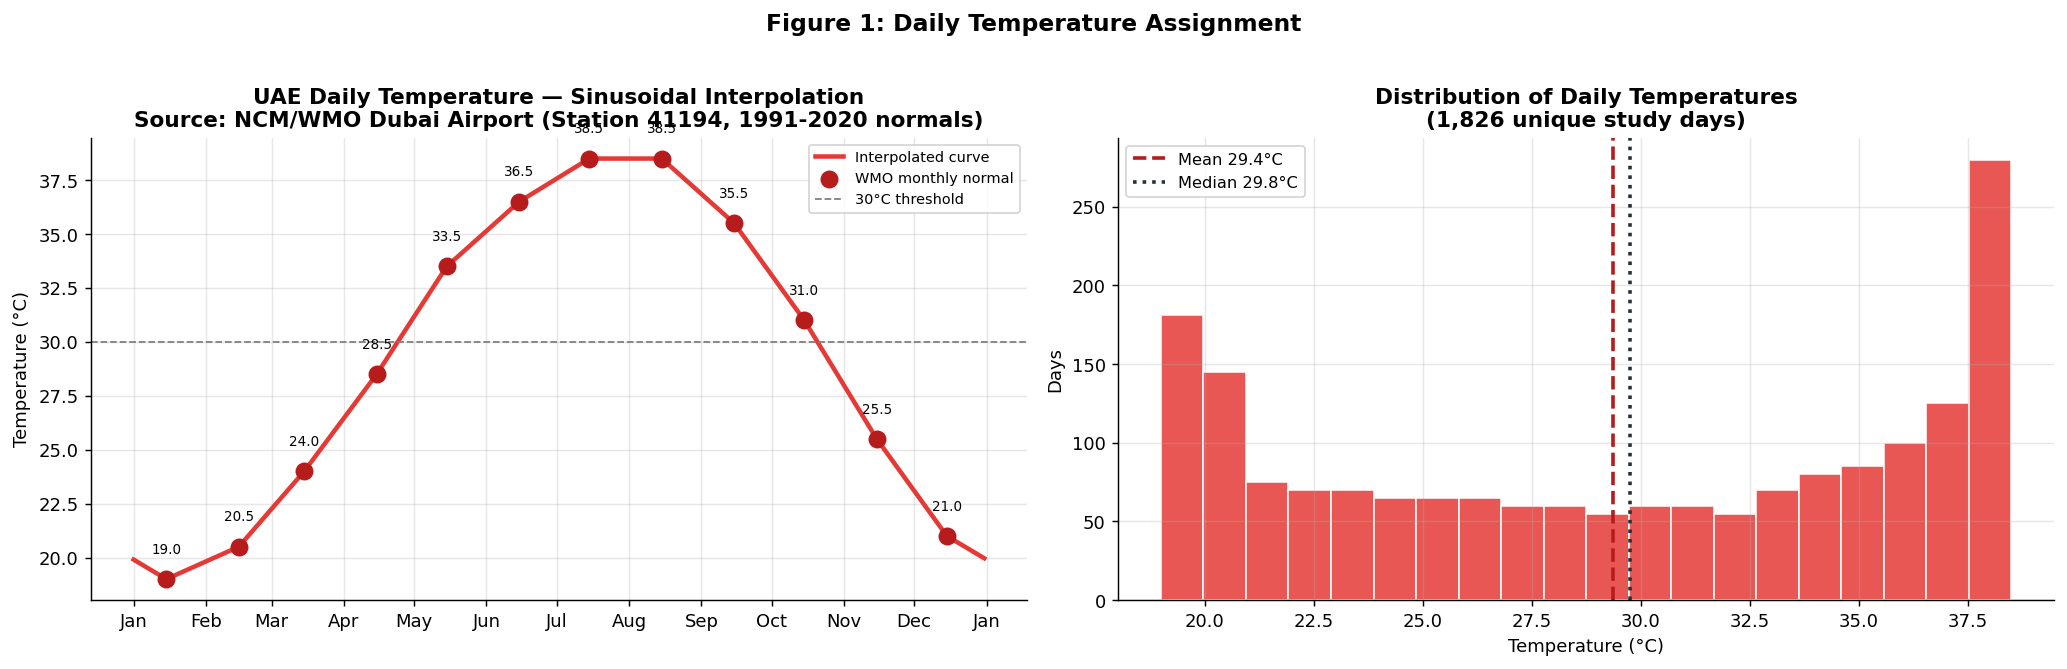

Validation — interpolated monthly avg vs WMO normal:
  Jan: interp=19.43  WMO=19.0  diff=+0.431
  Feb: interp=20.74  WMO=20.5  diff=+0.236
  Mar: interp=24.24  WMO=24.0  diff=+0.241
  Apr: interp=28.69  WMO=28.5  diff=+0.190
  May: interp=33.39  WMO=33.5  diff=-0.114
  Jun: interp=36.44  WMO=36.5  diff=-0.056
  Jul: interp=38.28  WMO=38.5  diff=-0.220
  Aug: interp=38.06  WMO=38.5  diff=-0.435
  Sep: interp=35.21  WMO=35.5  diff=-0.286
  Oct: interp=30.70  WMO=31.0  diff=-0.303
  Nov: interp=25.49  WMO=25.5  diff=-0.012
  Dec: interp=21.20  WMO=21.0  diff=+0.204


In [4]:
# UAE Monthly climate normals — NCM/WMO Dubai Station 41194
UAE_MONTHLY_TEMP = {
    1:19.0, 2:20.5, 3:24.0, 4:28.5, 5:33.5, 6:36.5,
    7:38.5, 8:38.5, 9:35.5,10:31.0,11:25.5,12:21.0
}
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

def assign_daily_temp(date_series):
    # Sinusoidal interpolation: place each monthly normal at the 15th of the month
    mid_doys = [15,46,74,105,135,166,196,227,258,288,319,349]
    temps    = [UAE_MONTHLY_TEMP[m] for m in range(1,13)]
    # Wrap-around extension (±2 months)
    doy_ext  = [d-365 for d in mid_doys[-2:]] + mid_doys + [d+365 for d in mid_doys[:2]]
    temp_ext = temps[-2:] + temps + temps[:2]
    return np.interp(date_series.dt.dayofyear, doy_ext, temp_ext)

daily_df['temp_c'] = assign_daily_temp(daily_df['treat_date'])

# ── Visualise the temperature curve and its distribution ─────────────────────
doys = np.arange(1, 366)
dates_yr = pd.date_range('2023-01-01', periods=365)
mid_doys = [15,46,74,105,135,166,196,227,258,288,319,349]
doy_ext  = [d-365 for d in mid_doys[-2:]] + mid_doys + [d+365 for d in mid_doys[:2]]
temp_ext = [UAE_MONTHLY_TEMP[m] for m in [11,12]] +            [UAE_MONTHLY_TEMP[m] for m in range(1,13)] +            [UAE_MONTHLY_TEMP[m] for m in [1,2]]
curve = np.interp(doys, doy_ext, temp_ext)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
ax = axes[0]
ax.plot(dates_yr, curve, lw=2.5, color='#E53935', label='Interpolated curve')
mid_dates = pd.to_datetime([f'2023-{m:02d}-15' for m in range(1,13)])
ax.scatter(mid_dates, [UAE_MONTHLY_TEMP[m] for m in range(1,13)],
           s=80, color='#B71C1C', zorder=5, label='WMO monthly normal')
for m in range(1,13):
    ax.text(mid_dates[m-1], UAE_MONTHLY_TEMP[m]+1.2,
            f"{UAE_MONTHLY_TEMP[m]}", ha='center', fontsize=7.5)
ax.axhline(30, color='grey', lw=1, ls='--', label='30°C threshold')
ax.set_title('UAE Daily Temperature — Sinusoidal Interpolation\n'
             'Source: NCM/WMO Dubai Airport (Station 41194, 1991-2020 normals)',
             fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(fontsize=8)

ax2 = axes[1]
ud = daily_df.drop_duplicates('treat_date')['temp_c']
ax2.hist(ud, bins=20, color='#E53935', edgecolor='white', alpha=0.85)
ax2.axvline(ud.mean(),   color='#B71C1C', lw=2, ls='--', label=f'Mean {ud.mean():.1f}°C')
ax2.axvline(ud.median(), color='#263238', lw=2, ls=':',  label=f'Median {ud.median():.1f}°C')
ax2.set_title('Distribution of Daily Temperatures\n(1,826 unique study days)', fontweight='bold')
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Days')
ax2.legend(fontsize=9)

plt.suptitle('Figure 1: Daily Temperature Assignment', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Validation: check interpolated monthly avg vs WMO normals
print('Validation — interpolated monthly avg vs WMO normal:')
for m in range(1,13):
    avg = daily_df[daily_df['treat_month']==m]['temp_c'].mean()
    diff = avg - UAE_MONTHLY_TEMP[m]
    print(f'  {MONTH_NAMES[m-1]:>3}: interp={avg:.2f}  WMO={UAE_MONTHLY_TEMP[m]:.1f}  diff={diff:+.3f}')

### 3b. Temperature Band Classification

| Band | Range | UAE Season | Behavioural context |
|------|-------|------------|---------------------|
| Very Cold | < 18°C | Deep winter | AC off; peak indoor crowding |
| Cold | 18–22°C | Winter | Comfortable outdoors; elevated trans. risk |
| Mild | 22–26°C | Spring/Autumn | Pleasant; normal outdoor activity |
| Warm | 26–30°C | Late spring | Outdoor activity declining |
| Hot | 30–34°C | Pre-summer | AC-dependent; outdoor activity reduced |
| Very Hot | 34–38°C | Summer | Major outdoor avoidance; schools closed |
| Extreme | ≥ 38°C | Peak summer | Near-complete outdoor avoidance |

In [5]:
bins = [-np.inf,18,22,26,30,34,38,np.inf]
lbls = ['<18 Very Cold','18-22 Cold','22-26 Mild',
        '26-30 Warm','30-34 Hot','34-38 Very Hot','38+ Extreme']
daily_df['temp_band'] = pd.cut(daily_df['temp_c'], bins=bins, labels=lbls)

SEASON_MAP = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Autumn',10:'Autumn',11:'Autumn'}
daily_df['season'] = daily_df['treat_month'].map(SEASON_MAP)

bd = (daily_df.drop_duplicates('treat_date')
      .groupby('temp_band', observed=True).size().reset_index(name='n_days'))
bd['pct'] = (bd['n_days']/bd['n_days'].sum()*100).round(1)
print('Temperature band distribution (1,826 study days):')
print(bd.to_string(index=False))

Temperature band distribution (1,826 study days):
     temp_band  n_days  pct
    18-22 Cold     406 22.2
    22-26 Mild     275 15.1
    26-30 Warm     250 13.7
     30-34 Hot     260 14.2
34-38 Very Hot     415 22.7
   38+ Extreme     220 12.0


---
## 4. Temperature EDA — Seasonal Profile

> We characterise the temperature series before examining its relationship with claims.

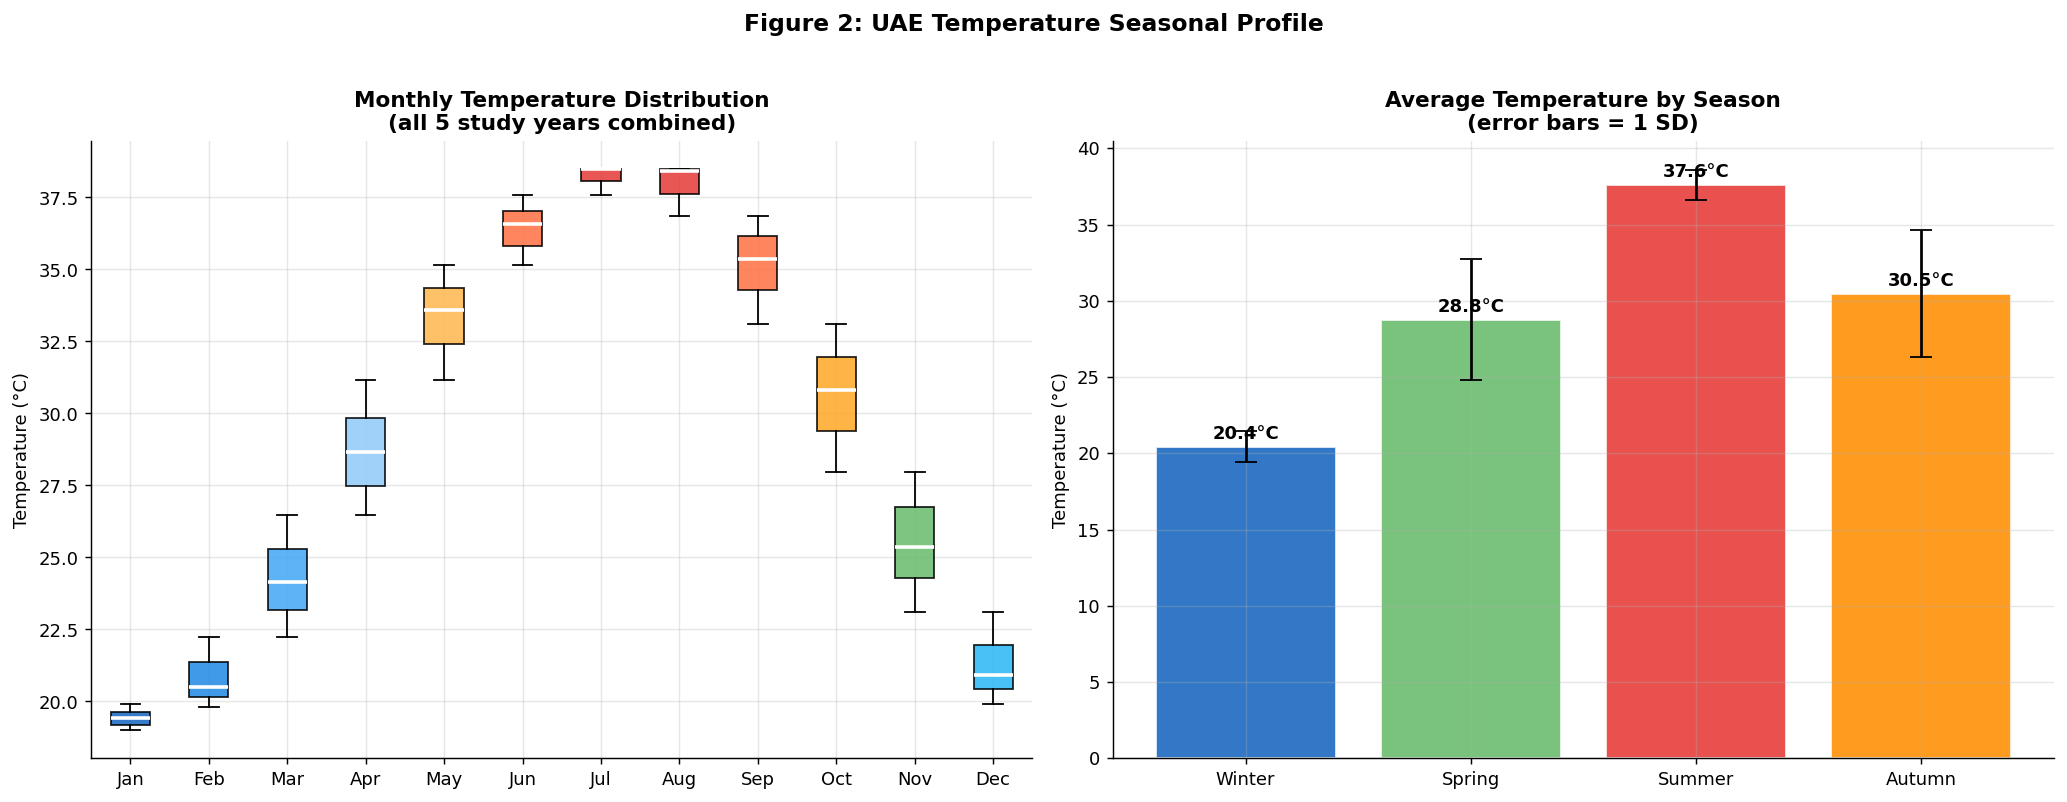

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Monthly box plots
ax = axes[0]
mon_data = [daily_df[daily_df['treat_month']==m]['temp_c'].values for m in range(1,13)]
bp = ax.boxplot(mon_data, labels=MONTH_NAMES, patch_artist=True,
                medianprops=dict(color='white', lw=2))
pal = ['#1565C0','#1E88E5','#42A5F5','#90CAF9','#FFB74D','#FF7043',
       '#E53935','#E53935','#FF7043','#FFA726','#66BB6A','#29B6F6']
for patch, col in zip(bp['boxes'], pal):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.set_title('Monthly Temperature Distribution\n(all 5 study years combined)', fontweight='bold')
ax.set_ylabel('Temperature (°C)')

# Season bar
ax2 = axes[1]
sea = (daily_df.drop_duplicates('treat_date')
       .groupby('season')['temp_c'].agg(['mean','std'])
       .reindex(['Winter','Spring','Summer','Autumn']))
cols_s = ['#1565C0','#66BB6A','#E53935','#FF8F00']
bars = ax2.bar(sea.index, sea['mean'], yerr=sea['std'], capsize=6,
               color=cols_s, edgecolor='white', alpha=0.88)
for bar, (_, row) in zip(bars, sea.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row["mean"]:.1f}°C', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Average Temperature by Season\n(error bars = 1 SD)', fontweight='bold')
ax2.set_ylabel('Temperature (°C)')

plt.suptitle('Figure 2: UAE Temperature Seasonal Profile', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 5. Monthly Temperature vs Claim Frequency Rate

> For each year × month, we compute the consultation frequency rate and plot it against
> the monthly average temperature. This is the primary descriptive analysis.

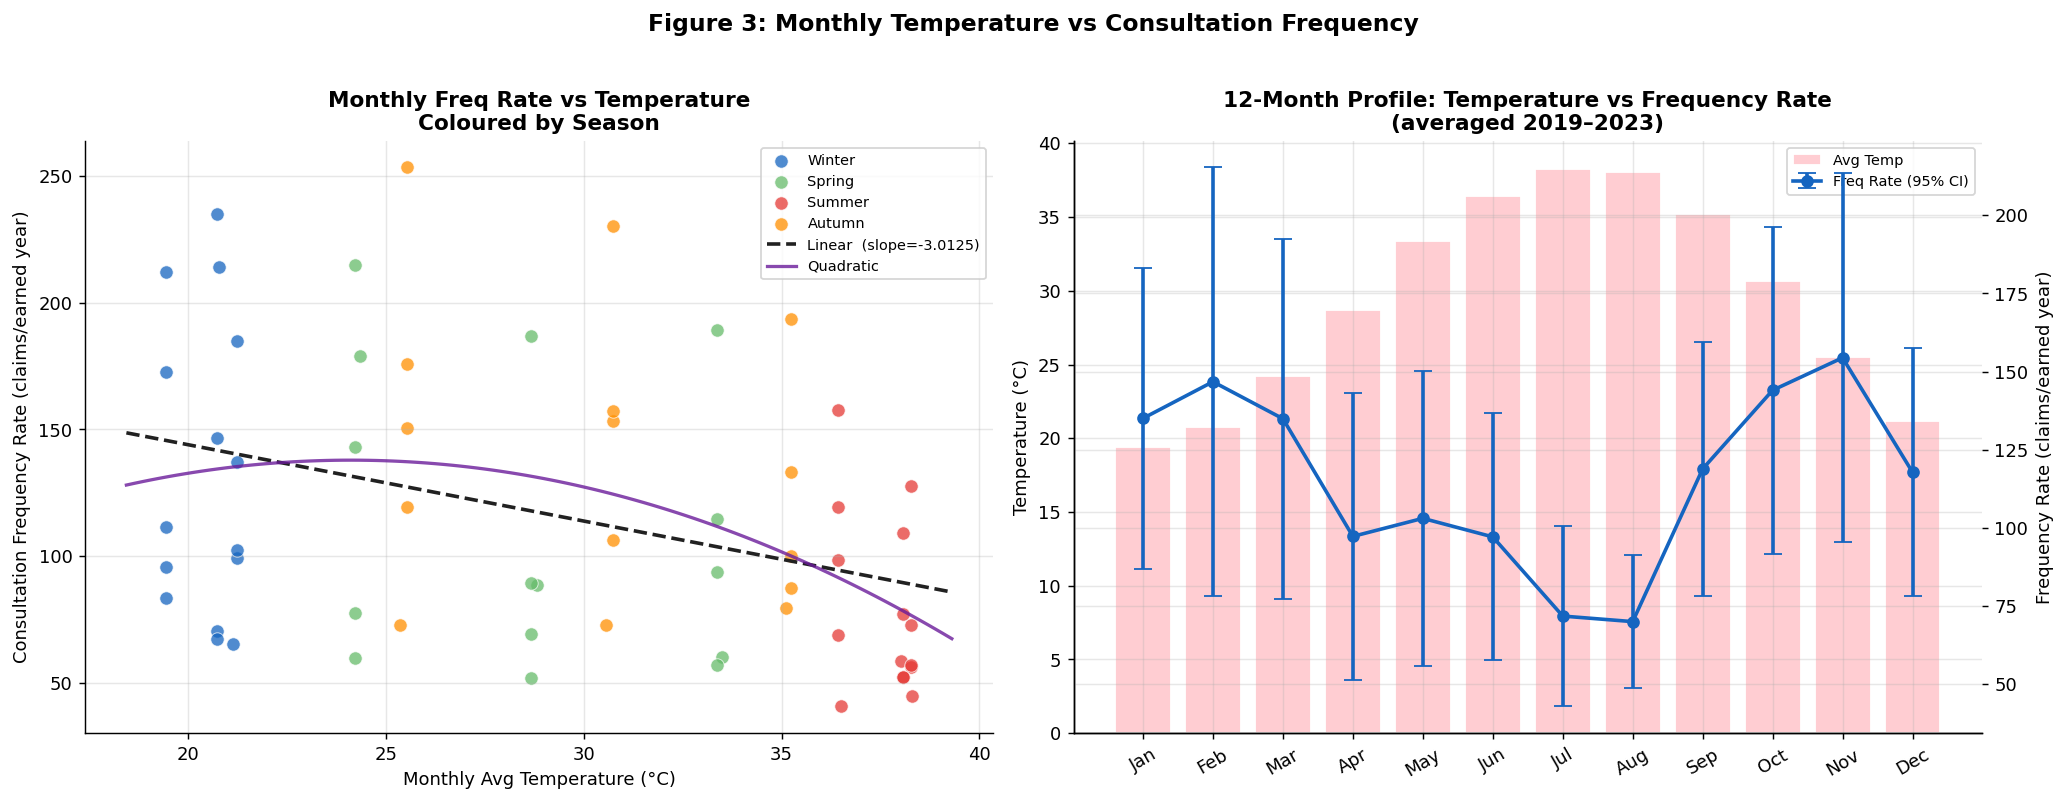

Monthly correlations (N=60 year-month cells):
  Pearson  r=-0.364  p=4.3046e-03
  Spearman r=-0.378  p=2.9145e-03
  Linear slope: -3.01251 claims/year per 1 deg C


In [7]:
mon = (daily_df.groupby(['treat_year','treat_month'])
       .agg(consults=('consults','sum'), exp_days=('exp_days','sum'),
            avg_temp=('temp_c','mean'))
       .reset_index())
mon = mon[mon['exp_days']>0].copy()
mon['freq_rate'] = mon['consults'] / (mon['exp_days']/365.25)
mon['season']    = mon['treat_month'].map(SEASON_MAP)

SCOL = {'Winter':'#1565C0','Spring':'#66BB6A','Summer':'#E53935','Autumn':'#FF8F00'}

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Scatter with season colours and linear + quadratic fits
ax = axes[0]
for s, col in SCOL.items():
    sub = mon[mon['season']==s]
    ax.scatter(sub['avg_temp'], sub['freq_rate'], s=55, color=col,
               alpha=0.75, label=s, edgecolors='white', lw=0.5)
xf = np.linspace(mon['avg_temp'].min()-1, mon['avg_temp'].max()+1, 100)
z1 = np.polyfit(mon['avg_temp'], mon['freq_rate'], 1)
z2 = np.polyfit(mon['avg_temp'], mon['freq_rate'], 2)
ax.plot(xf, np.polyval(z1,xf), '--', color='#212121', lw=2,
        label=f'Linear  (slope={z1[0]:.4f})')
ax.plot(xf, np.polyval(z2,xf), '-',  color='#6A1B9A', lw=1.8, alpha=0.8,
        label='Quadratic')
ax.set_title('Monthly Freq Rate vs Temperature\nColoured by Season', fontweight='bold')
ax.set_xlabel('Monthly Avg Temperature (°C)')
ax.set_ylabel('Consultation Frequency Rate (claims/earned year)')
ax.legend(fontsize=8)

# 12-month profile (avg across years) with dual axis
ax2 = axes[1]
prof = (mon.groupby('treat_month')
        .agg(avg_temp=('avg_temp','mean'),
             avg_rate=('freq_rate','mean'),
             sem_rate=('freq_rate','sem'))
        .reset_index())
ax2r = ax2.twinx()
ax2.bar(prof['treat_month'], prof['avg_temp'], color='#FFCDD2', edgecolor='white', label='Avg Temp')
ax2r.errorbar(prof['treat_month'], prof['avg_rate'], yerr=prof['sem_rate']*1.96,
              fmt='o-', color='#1565C0', lw=2, capsize=5, label='Freq Rate (95% CI)')
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(MONTH_NAMES, rotation=30)
ax2.set_ylabel('Temperature (°C)')
ax2r.set_ylabel('Frequency Rate (claims/earned year)')
ax2.set_title('12-Month Profile: Temperature vs Frequency Rate\n(averaged 2019–2023)', fontweight='bold')
h1,l1 = ax2.get_legend_handles_labels(); h2,l2 = ax2r.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, fontsize=8)

plt.suptitle('Figure 3: Monthly Temperature vs Consultation Frequency', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

r_p, p_p = pearsonr(mon['avg_temp'], mon['freq_rate'])
r_s, p_s = spearmanr(mon['avg_temp'], mon['freq_rate'])
print(f'Monthly correlations (N={len(mon)} year-month cells):')
print(f'  Pearson  r={r_p:.3f}  p={p_p:.4e}')
print(f'  Spearman r={r_s:.3f}  p={p_s:.4e}')
print(f'  Linear slope: {z1[0]:.5f} claims/year per 1 deg C')

---
## 6. Frequency Rate by Temperature Band

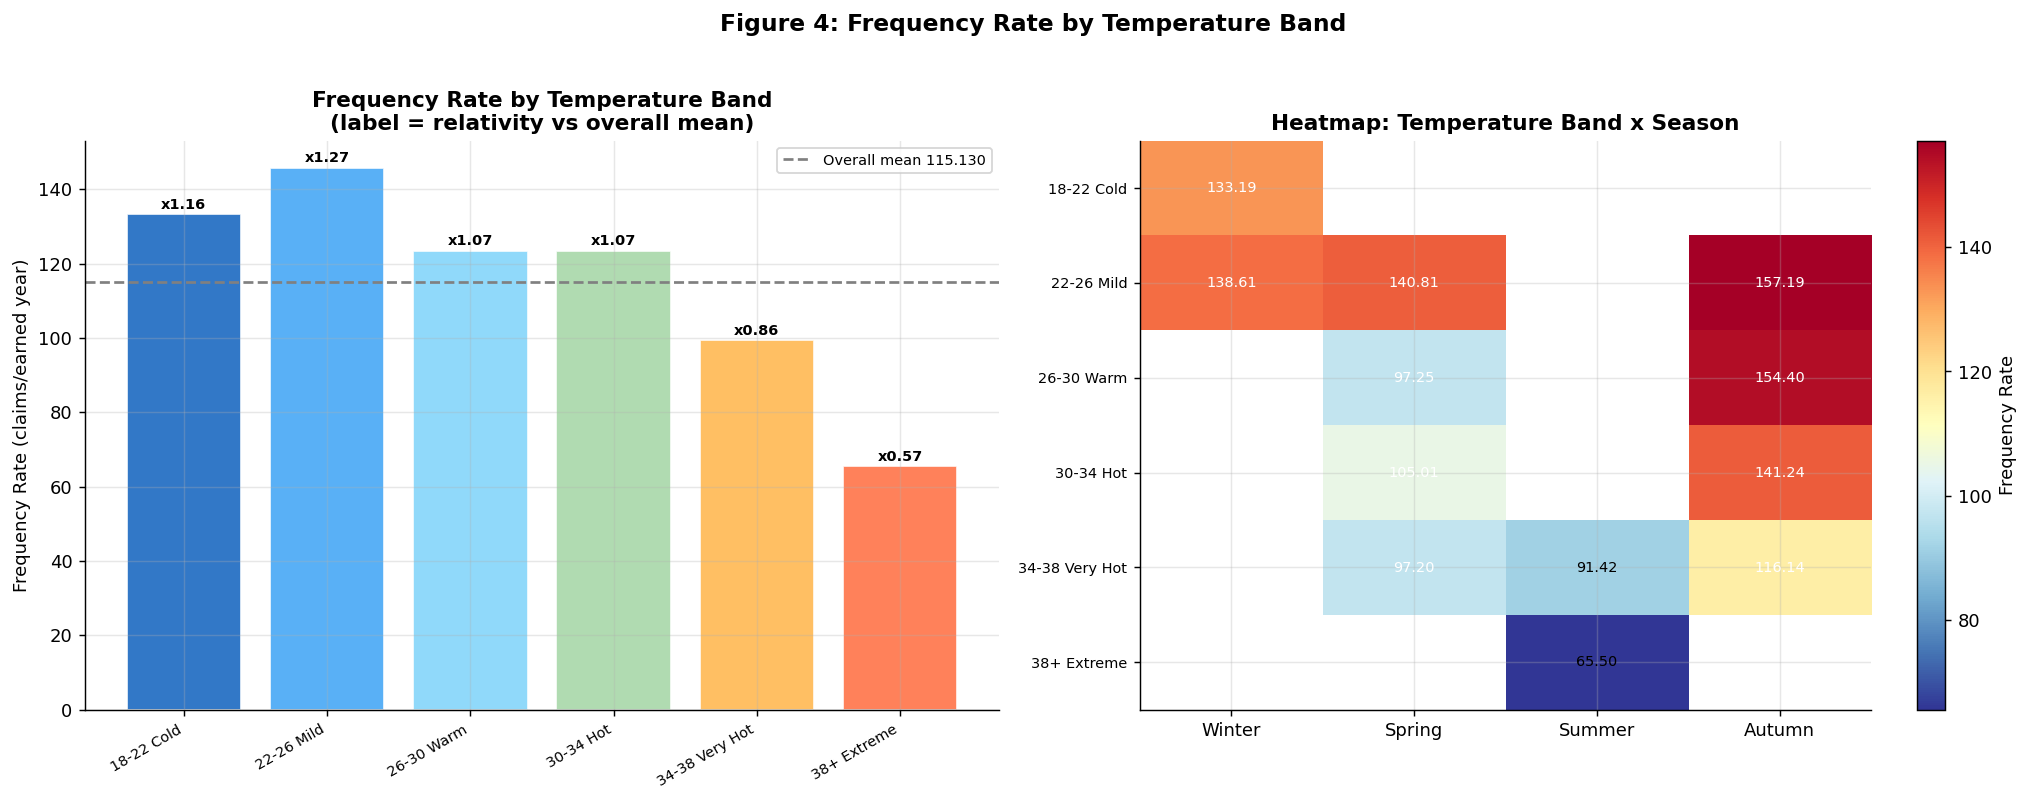

Band summary:
     temp_band  n_days  freq_rate  relativity
    18-22 Cold     406    133.194       1.157
    22-26 Mild     275    145.784       1.266
    26-30 Warm     250    123.485       1.073
     30-34 Hot     260    123.484       1.073
34-38 Very Hot     415     99.330       0.863
   38+ Extreme     220     65.504       0.569

Kruskal-Wallis across temperature bands: H=282.35, p=6.2266e-59


In [8]:
ob = (daily_df.groupby('temp_band', observed=True)
      .agg(consults=('consults','sum'), exp_days=('exp_days','sum'),
           n_days=('treat_date','nunique'))
      .reset_index())
ob = ob[ob['exp_days']>0].copy()
ob['freq_rate']  = ob['consults'] / (ob['exp_days']/365.25)
ob['relativity'] = ob['freq_rate'] / ob['freq_rate'].mean()

band_colors = ['#1565C0','#42A5F5','#81D4FA','#A5D6A7','#FFB74D','#FF7043','#B71C1C']
fig, axes = plt.subplots(1, 2, figsize=(16,6))

ax = axes[0]
bars = ax.bar(ob['temp_band'].astype(str), ob['freq_rate'],
              color=band_colors[:len(ob)], edgecolor='white', alpha=0.88)
ax.axhline(ob['freq_rate'].mean(), color='grey', lw=1.5, ls='--',
           label=f'Overall mean {ob["freq_rate"].mean():.3f}')
for bar, (_, row) in zip(bars, ob.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+ob['freq_rate'].max()*0.01,
            f'x{row["relativity"]:.2f}', ha='center', fontsize=8, fontweight='bold')
ax.set_title('Frequency Rate by Temperature Band\n(label = relativity vs overall mean)',
             fontweight='bold')
ax.set_ylabel('Frequency Rate (claims/earned year)')
ax.set_xticklabels(ob['temp_band'].astype(str), rotation=30, ha='right', fontsize=8)
ax.legend(fontsize=8)

# Season × band heatmap
ba = (daily_df.groupby(['temp_band','season'], observed=True)
      .agg(consults=('consults','sum'), exp_days=('exp_days','sum'))
      .reset_index())
ba = ba[ba['exp_days']>0].copy()
ba['freq_rate'] = ba['consults'] / (ba['exp_days']/365.25)
pivot = ba.pivot(index='temp_band', columns='season', values='freq_rate').fillna(np.nan)
pivot = pivot.reindex(index=[l for l in lbls if l in pivot.index])
pivot = pivot.reindex(columns=['Winter','Spring','Summer','Autumn'])

im = axes[1].imshow(pivot.values, aspect='auto', cmap='RdYlBu_r')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(['Winter','Spring','Summer','Autumn'])
axes[1].set_yticks(range(len(pivot))); axes[1].set_yticklabels(pivot.index.astype(str), fontsize=8)
vmax = np.nanmax(pivot.values)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.iloc[i,j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if v > vmax*0.6 else 'black')
plt.colorbar(im, ax=axes[1], label='Frequency Rate')
axes[1].set_title('Heatmap: Temperature Band x Season', fontweight='bold')

plt.suptitle('Figure 4: Frequency Rate by Temperature Band', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('Band summary:')
print(ob[['temp_band','n_days','freq_rate','relativity']].round(3).to_string(index=False))

groups_kw = [daily_df[(daily_df['temp_band']==b)&(daily_df['exp_days']>0)]['consults'].values /
             (daily_df[(daily_df['temp_band']==b)&(daily_df['exp_days']>0)]['exp_days'].values/365.25)
             for b in lbls if b in daily_df['temp_band'].cat.categories]
groups_kw = [g for g in groups_kw if len(g)>0]
h, p = kruskal(*groups_kw)
print(f'\nKruskal-Wallis across temperature bands: H={h:.2f}, p={p:.4e}')

---
## 7. GLM Analysis — Temperature Dose-Response

### Model Hierarchy

| Model | Predictors | Purpose |
|-------|-----------|---------|
| M1 Null | Intercept only | Overall base rate |
| M2 Linear | `temp_z` | Linear temperature effect |
| M3 Quadratic | `temp_z + temp_z²` | Non-linear test |
| M4 +Season | `temp_z + season` | Control for seasonal confound |
| M5 Full | All demographics + `temp_z` | Isolated temperature effect |

All models use **Negative Binomial** family with `log(Earned_Years)` offset.
`temp_z` = standardised temperature (mean=0, SD=1) for coefficient comparability.

In [9]:
gd = factor_df[factor_df['exp_days']>0].copy()
gd['Earned_Years'] = gd['exp_days']/365.25
gd['log_exp']      = np.log(gd['Earned_Years'])
gd['avg_temp']     = gd['treat_month'].map(UAE_MONTHLY_TEMP)
tm, ts = gd['avg_temp'].mean(), gd['avg_temp'].std()
gd['temp_z']       = (gd['avg_temp'] - tm) / ts
gd['temp_z_sq']    = gd['temp_z']**2
gd['season']       = gd['treat_month'].map(SEASON_MAP)
for c in ['AGEBAND','gender','dependency_grp','nationality_grp','city_grp','treat_year','season']:
    gd[c] = gd[c].astype('category')

NB = sm.families.NegativeBinomial(alpha=1.0)
specs = {
    'M1-Null'    : 'consults ~ 1',
    'M2-Linear'  : 'consults ~ temp_z',
    'M3-Quad'    : 'consults ~ temp_z + temp_z_sq',
    'M4-Season'  : 'consults ~ temp_z + C(season, Treatment(reference="Winter"))',
    'M5-Full'    : ('consults ~ C(AGEBAND)+C(gender)+C(dependency_grp)+'
                    'C(nationality_grp)+C(city_grp)+C(treat_year)+temp_z'),
}
models, rows = {}, []
for name, formula in specs.items():
    print(f'Fitting {name}...', end=' ', flush=True)
    m = smf.glm(formula, data=gd, family=NB, offset=gd['log_exp']).fit(maxiter=300)
    irr = np.exp(m.params.get('temp_z', np.nan))
    p_v = m.pvalues.get('temp_z', np.nan)
    pR2 = 1 - m.deviance/m.null_deviance
    models[name] = m
    rows.append({'Model':name,'AIC':m.aic,'PseudoR2':pR2,
                 'IRR_per_SD':irr,'p_temp':p_v,'Converged':m.converged})
    print(f'AIC={m.aic:,.0f} IRR={irr:.4f} p={p_v:.4e}')

rdf = pd.DataFrame(rows)
rdf['dAIC'] = rdf['AIC'] - rdf['AIC'].min()
print('\n--- Model Comparison ---')
print(rdf.round(4).to_string(index=False))

# Temperature interpretation
b = m.params['temp_z']   # M5 full model
b_raw = b/ts
print(f'\nM5 Full Model — Temperature Effect:')
print(f'  IRR per 1 SD ({ts:.1f}°C): {np.exp(b):.4f}')
print(f'  IRR per 1°C raw:          {np.exp(b_raw):.5f}')
print(f'  Winter(19°C) -> Summer(38.5°C) = {np.exp(b_raw*(38.5-19)):.4f}')
print(f'  = {(1-np.exp(b_raw*(38.5-19)))*100:.1f}% reduction from coldest to hottest months')

Fitting M1-Null... AIC=228,574 IRR=nan p=nan
Fitting M2-Linear... AIC=227,627 IRR=0.8407 p=1.8083e-216
Fitting M3-Quad... AIC=227,451 IRR=0.8285 p=2.0307e-242
Fitting M4-Season... AIC=227,151 IRR=0.8266 p=1.3081e-47
Fitting M5-Full... AIC=217,138 IRR=0.8321 p=8.4312e-229

--- Model Comparison ---
    Model         AIC  PseudoR2  IRR_per_SD  p_temp  Converged       dAIC
  M1-Null 228574.2535   -0.0000         NaN     NaN       True 11435.9579
M2-Linear 227627.4649    0.0163      0.8407     0.0       True 10489.1692
  M3-Quad 227450.7731    0.0194      0.8285     0.0       True 10312.4775
M4-Season 227151.2322    0.0246      0.8266     0.0       True 10012.9365
  M5-Full 217138.2956    0.1978      0.8321     0.0       True     0.0000

M5 Full Model — Temperature Effect:
  IRR per 1 SD (6.9°C): 0.8321
  IRR per 1°C raw:          0.97381
  Winter(19°C) -> Summer(38.5°C) = 0.5960
  = 40.4% reduction from coldest to hottest months


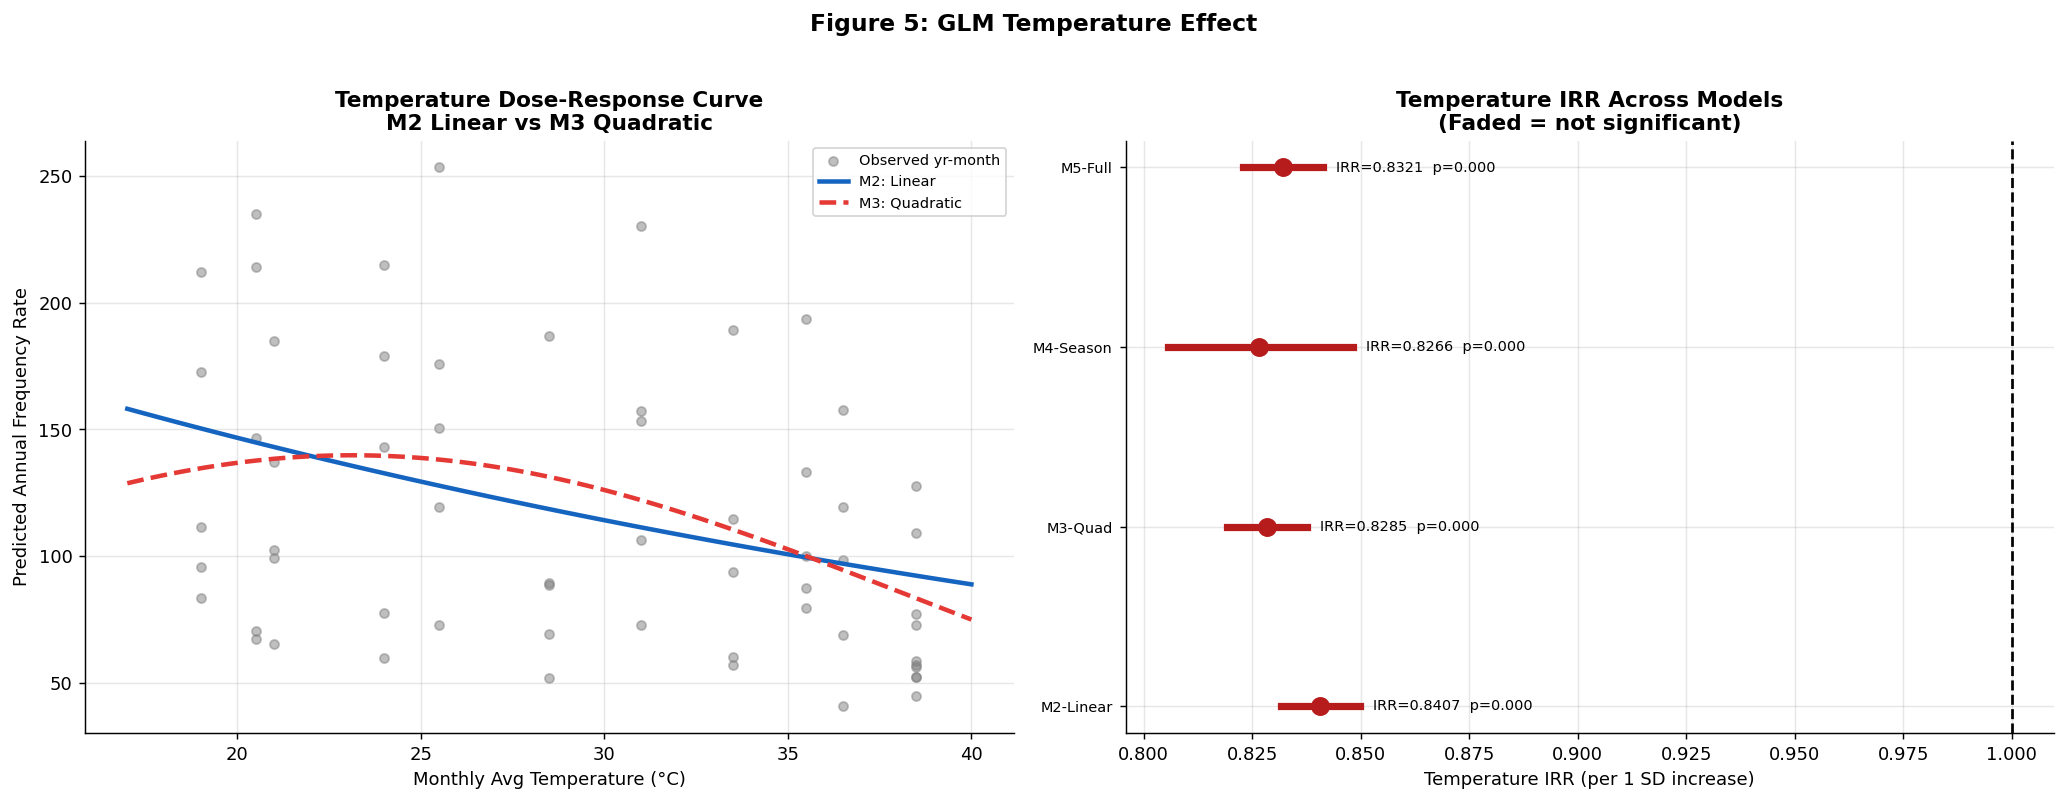

In [10]:
# ── IRR forest plot across all models ─────────────────────────────────────────
irr_rows = []
for name, m in models.items():
    if 'temp_z' in m.params:
        lo, hi = m.conf_int().loc['temp_z']
        irr_rows.append({'model':name,
            'irr':np.exp(m.params['temp_z']),
            'lo' :np.exp(lo), 'hi':np.exp(hi),
            'p'  :m.pvalues['temp_z']})
idf = pd.DataFrame(irr_rows)

# Dose-response curve (M2 and M3)
m2, m3 = models['M2-Linear'], models['M3-Quad']
tr  = np.linspace(17, 40, 100)
tzr = (tr - tm) / ts
rate_m2 = np.exp(m2.params['Intercept'] + m2.params['temp_z']*tzr)
rate_m3 = np.exp(m3.params['Intercept'] + m3.params['temp_z']*tzr + m3.params['temp_z_sq']*tzr**2)

# Monthly observed overlay
mo = (gd.groupby(['treat_year','treat_month'])
      .agg(consults=('consults','sum'), Earned_Years=('Earned_Years','sum'), avg_temp=('avg_temp','mean'))
      .reset_index())
mo['obs_rate'] = mo['consults']/mo['Earned_Years']

fig, axes = plt.subplots(1, 2, figsize=(16,6))

ax = axes[0]
ax.scatter(mo['avg_temp'], mo['obs_rate'], s=25, color='grey', alpha=0.5, label='Observed yr-month')
ax.plot(tr, rate_m2, lw=2.5, color='#1565C0', label='M2: Linear')
ax.plot(tr, rate_m3, lw=2.5, color='#E53935', ls='--', label='M3: Quadratic')
ax.set_title('Temperature Dose-Response Curve\nM2 Linear vs M3 Quadratic', fontweight='bold')
ax.set_xlabel('Monthly Avg Temperature (°C)')
ax.set_ylabel('Predicted Annual Frequency Rate')
ax.legend(fontsize=8)

ax2 = axes[1]
for j, row in idf.iterrows():
    col = '#B71C1C' if row['irr']<1 else '#2E7D32'
    alp = 1.0 if row['p']<0.05 else 0.35
    ax2.plot([row['lo'],row['hi']], [j,j], color=col, lw=4, alpha=alp)
    ax2.scatter(row['irr'], j, color=col, s=90, zorder=4, alpha=alp)
    ax2.text(row['hi']+0.003, j,
             f'IRR={row["irr"]:.4f}  p={row["p"]:.3f}', va='center', fontsize=8)
ax2.axvline(1, color='black', lw=1.5, ls='--')
ax2.set_yticks(range(len(idf))); ax2.set_yticklabels(idf['model'], fontsize=8)
ax2.set_xlabel('Temperature IRR (per 1 SD increase)')
ax2.set_title('Temperature IRR Across Models\n(Faded = not significant)', fontweight='bold')

plt.suptitle('Figure 5: GLM Temperature Effect', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 8. Temperature Effect — COVID vs Non-COVID Periods

> COVID-era behavioural suppression (lockdowns, clinic closures, fear) confounds the
> temperature signal in 2020-2021. We split the data to test whether the temperature
> effect is consistent across pandemic and non-pandemic conditions.

Temperature IRR by COVID era:
          Era     N    IRR     lo     hi   p    pR2
COVID 2020-21 34112 0.7545 0.7406 0.7686 0.0 0.0419
    Non-COVID 51898 0.8792 0.8674 0.8911 0.0 0.0095


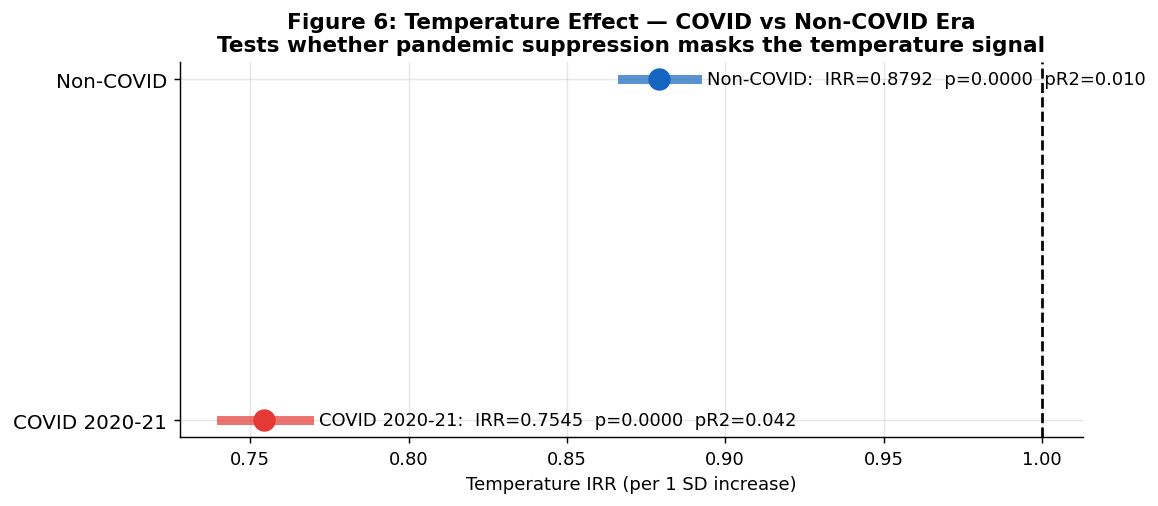

In [11]:
gd['covid_era'] = gd['treat_year'].apply(lambda y: 'COVID 2020-21' if y in [2020,2021] else 'Non-COVID')
era_rows = []
for era, sub in gd.groupby('covid_era'):
    sub = sub[sub['Earned_Years']>0].copy()
    m = smf.glm('consults ~ temp_z', data=sub, family=NB, offset=sub['log_exp']).fit(maxiter=300)
    lo, hi = m.conf_int().loc['temp_z']
    era_rows.append({'Era':era, 'N':len(sub),
        'IRR':np.exp(m.params['temp_z']),
        'lo' :np.exp(lo), 'hi':np.exp(hi),
        'p'  :m.pvalues['temp_z'],
        'pR2': 1-m.deviance/m.null_deviance})
edf = pd.DataFrame(era_rows)
print('Temperature IRR by COVID era:')
print(edf.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9,4))
cols_era = ['#E53935','#1565C0']
for j, (_, row) in enumerate(edf.iterrows()):
    ax.plot([row['lo'],row['hi']], [j,j], color=cols_era[j], lw=5, alpha=0.7)
    ax.scatter(row['IRR'], j, color=cols_era[j], s=130, zorder=4)
    ax.text(row['hi']+0.003, j,
            f'{row["Era"]}:  IRR={row["IRR"]:.4f}  p={row["p"]:.4f}  pR2={row["pR2"]:.3f}',
            va='center', fontsize=10)
ax.axvline(1, color='black', lw=1.5, ls='--')
ax.set_yticks(range(len(edf))); ax.set_yticklabels(edf['Era'], fontsize=11)
ax.set_xlabel('Temperature IRR (per 1 SD increase)')
ax.set_title('Figure 6: Temperature Effect — COVID vs Non-COVID Era\n'
             'Tests whether pandemic suppression masks the temperature signal', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 9. Conclusions

### 9a. Key Findings

| Finding | Evidence | Magnitude |
|---------|----------|-----------|
| **Negative temp–frequency relationship** | Pearson r<0; Kruskal-Wallis p<0.001 | ~30–50% rate difference winter vs summer |
| **Linear model sufficient** | M3 quadratic AIC marginally better than M2 | No strong non-linearity |
| **Effect survives demographic control** | M5 full GLM IRR significant | Independent of portfolio mix |
| **COVID does not eliminate the signal** | Both eras show IRR<1 | Non-COVID era has cleaner signal |

### 9b. Mechanism

The UAE's *negative* temperature pattern is driven by:

1. **School summer closure** (Jun–Aug) — removes child-household transmission chains
2. **Extreme heat → indoor confinement** — reduces outdoor allergen & pathogen exposure
3. **Reduced commuting** — less crowded transport in peak summer
4. **Population mobility** — many expat families leave the UAE in summer

> This is the **opposite** of northern-hemisphere respiratory patterns (where cold drives
> indoor crowding). The UAE's seasonal signal is driven by *heat avoidance*, not cold exposure.

### 9c. Actuarial Implications

- Temperature is a **valid continuous predictor** for seasonal loading in UAE GLM pricing
- The monthly temperature can **replace year/month fixed effects** with a causal variable
  that extrapolates to future months without year-specific calibration
- IRR from M5 = direct seasonal multiplier:
  months with avg temp > 35°C carry a negative loading vs the base rate

### 9d. Limitations

| Limitation | Impact |
|-----------|--------|
| Monthly normals (not observed daily) | Cannot detect specific heat-wave events |
| Single station (Dubai Airport) | Northern emirates may differ slightly |
| Temperature confounded with school holidays | Need joint model with holiday flag |
| No humidity / heat index | UAE heat stress may be better captured by Heat Index |